<a href="https://colab.research.google.com/github/fino15/Machine-Learning-Assignment/blob/main/Machine_learning_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab/Project 1 - Weather Dataset.csv.csv')
# df = pd.read_csv('/content/Project 1 - Weather Dataset.csv.csv')
print(" Dataset successfully loaded into 'df'!\n")

 Dataset successfully loaded into 'df'!



In [3]:
#Step 1: Data cleaning
print("Checking for missing values")
#Count missing values in each column
missing_values = df.isnull().sum()
print(missing_values)

Checking for missing values
Date/Time           0
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64


In [4]:
print("\n2.Checking for deplicate rowss")
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")


2.Checking for deplicate rowss
Number of duplicate rows: 0


In [5]:
#Drop duplicates if any exist
if duplicate_count > 0:
  df.drop_dyplicates(inplace=True)
  print("Duplicate rows dropped successfully!")
else:
  print("No duplicate rows found!")

print("\n3.Verifying structural Dta Types")
print(df.dtypes)

No duplicate rows found!

3.Verifying structural Dta Types
Date/Time            object
Temp_C              float64
Dew Point Temp_C    float64
Rel Hum_%             int64
Wind Speed_km/h       int64
Visibility_km       float64
Press_kPa           float64
Weather              object
dtype: object


In [6]:
df['Weather'].value_counts()

,count
Weather,
Mainly Clear,2106
Mostly Cloudy,2069
Cloudy,1728
Clear,1326
Snow,390
Rain,306
Rain Showers,188
Fog,150
"Rain,Fog",116


In [7]:
# Function to merge/combine weather categories into major classes
def merge_weather_categories(weather_string):
    weather_string = str(weather_string).lower().strip()

    if 'thunderstorm' in weather_string:
        return 'Rain/Storm'
    elif 'freezing' in weather_string or 'snow' in weather_string or 'ice' in weather_string:
        return 'Snow/Ice'
    elif 'rain' in weather_string or 'drizzle' in weather_string:
        return 'Rain/Storm'
    elif 'fog' in weather_string or 'haze' in weather_string or 'mist' in weather_string:
        return 'Fog/Haze'
    elif 'cloudy' in weather_string:
        return 'Cloudy'
    elif 'clear' in weather_string:
        return 'Clear'
    return 'Cloudy'

# Apply the category merging logic
df['Weather'] = df['Weather'].apply(merge_weather_categories)

print(df['Weather'].value_counts())

Weather
Cloudy        3797
Clear         3432
Rain/Storm     763
Snow/Ice       626
Fog/Haze       166
Name: count, dtype: int64


In [8]:
#Data Transformation

from sklearn.preprocessing import LabelEncoder

print("Performing Feature Engineering on Date/Time")
df['Date/Time']= pd.to_datetime(df['Date/Time'])


df['Month'] = df['Date/Time'].dt.month
df['Hour'] = df['Date/Time'].dt.hour

#Calculate sequence changes BEFORE dropping the time metric
df['Temp_Dew_Diff'] = df['Temp_C'] - df['Dew Point Temp_C']
df['Press_Diff'] = df['Press_kPa'].diff().fillna(0)

#Drop the original text date column
df.drop('Date/Time', axis=1, inplace=True)
print("Extracted 'Month' and 'Hour' columns")

print("\nEncoding Text Labels in the Weather Column")
label_encoder = LabelEncoder()
df['Weather_Encoded'] = label_encoder.fit_transform(df['Weather'])

#Preview of newly transformed dataset
print("\nTransformed Dataset:")
print(df[['Month', 'Hour', 'Temp_C', 'Weather','Weather_Encoded']].head())


Performing Feature Engineering on Date/Time
Extracted 'Month' and 'Hour' columns

Encoding Text Labels in the Weather Column

Transformed Dataset:
   Month  Hour  Temp_C   Weather  Weather_Encoded
0      1     0    -1.8  Fog/Haze                2
1      1     1    -1.8  Fog/Haze                2
2      1     2    -1.8  Snow/Ice                4
3      1     3    -1.5  Snow/Ice                4
4      1     4    -1.5  Fog/Haze                2


In [9]:
#Step 3: Scaling and Data Reduction

from sklearn.preprocessing import StandardScaler
print("Data Reduction")
if 'Weather' in df.columns:
  df.drop('Weather', axis=1 , inplace=True)
  print("Dropped original string 'Weather' column")

  print("\nFeature Scaling")
  features_to_scale = ['Temp_C', 'Dew Point Temp_C','Rel Hum_%','Wind Speed_km/h','Press_kPa','Visibility_km','Month','Hour', 'Temp_Dew_Diff', 'Press_Diff']

scaler =StandardScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Final Ppipeline Preview")
print(df.head())

Data Reduction
Dropped original string 'Weather' column

Feature Scaling
Final Ppipeline Preview
     Temp_C  Dew Point Temp_C  Rel Hum_%  Wind Speed_km/h  Visibility_km  \
0 -0.906815         -0.593184   1.097553        -1.259808      -1.557954   
1 -0.906815         -0.574805   1.156662        -1.259808      -1.557954   
2 -0.906815         -0.547238   1.274879        -0.914513      -1.874862   
3 -0.881146         -0.528860   1.215770        -1.029611      -1.874862   
4 -0.881146         -0.538049   1.215770        -0.914513      -1.811480   

   Press_kPa     Month      Hour  Temp_Dew_Diff  Press_Diff  Weather_Encoded  
0   0.223206 -1.597591 -1.661325      -0.982966    0.002490                2  
1   0.223206 -1.597591 -1.516862      -1.030419    0.002490                2  
2   0.246904 -1.597591 -1.372399      -1.101600    0.326584                4  
3   0.258753 -1.597591 -1.227936      -1.077873    0.164537                4  
4   0.211358 -1.597591 -1.083473      -1.054146   -

# Part 2 : Training model


In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import KFold, cross_val_score

In [11]:
x = df.drop(columns=['Weather_Encoded'])
y = df['Weather_Encoded']

In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {}
models['knn'] = KNeighborsClassifier()
models['lgr'] = LogisticRegression(max_iter=1000)
models['gnb'] = GaussianNB()
models['dtc'] = DecisionTreeClassifier()
models['svc'] = SVC()
models['rfc'] = RandomForestClassifier()
models['gbc'] = GradientBoostingClassifier()
models['mlp'] = MLPClassifier(max_iter=500)

for n in models:
        scores = cross_val_score(models[n], x, y, cv=kf, n_jobs=-1)
        print(f'{n}: {scores.mean():.3%} +/- {scores.std():.3%}')

knn: 70.515% +/- 1.019%
lgr: 61.874% +/- 0.260%
gnb: 54.338% +/- 1.162%
dtc: 67.111% +/- 0.749%
svc: 67.145% +/- 0.965%
rfc: 76.822% +/- 0.889%
gbc: 69.513% +/- 0.170%
mlp: 68.909% +/- 0.624%


In [13]:
#rfc have a better performance, we gonna use rfc to do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'n_estimators': list((50, 100, 200, 300)),
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10]
}

rfc_base = RandomForestClassifier(class_weight='balanced', random_state=42)

random_search = RandomizedSearchCV(
    estimator=rfc_base,
    param_distributions=param_distributions,
    n_iter=10,
    cv=kf,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search.fit(x, y)
print(f"Highest accuracy of RFC after hyperparameter tuning: {random_search.best_score_:.3%}")
print(f"RFC Best Parameters: {random_search.best_params_}")

Highest accuracy of RFC after hyperparameter tuning: 77.277%
RFC Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 30}


In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200, 300]},
                   random_state=42, scoring='accuracy')

In [15]:
from sklearn.metrics import classification_report, accuracy_score

#Get the best model from the random search
best_rfc = random_search.best_estimator_

y_pred = best_rfc.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.83      0.79       665
           1       0.75      0.77      0.76       772
           2       0.84      0.72      0.78        36
           3       0.80      0.58      0.67       148
           4       0.88      0.74      0.80       136

    accuracy                           0.77      1757
   macro avg       0.81      0.73      0.76      1757
weighted avg       0.77      0.77      0.77      1757



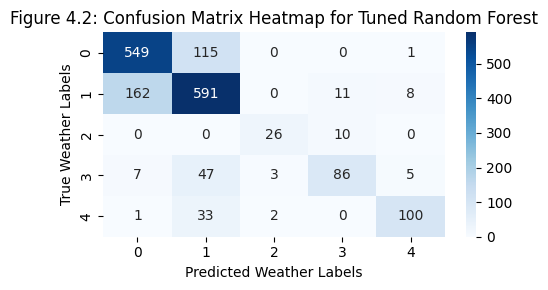

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Plot the Heatmap
plt.figure(figsize=(5, 3))
# xticklabels = class_names, yticklabels=class_names inside heatmap()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)

plt.title('Figure 4.2: Confusion Matrix Heatmap for Tuned Random Forest')
plt.xlabel('Predicted Weather Labels')
plt.ylabel('True Weather Labels')
plt.tight_layout()
plt.show()